<a href="https://colab.research.google.com/github/Palamarovski/Systemy/blob/main/Systemy_lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Імпорт та завантаження сирих даних

In [17]:
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
import seaborn as sns

csv_data = """ID;Сенсор;Вік_міс;Відмови_6міс;Батарея_%;Втрата_даних_%;Критичність_зони;Ремонт_грн;RSSI_dBm
IOT-01;Sensor-1;3;6;29;10.0;Низька;3678;-84
IOT-02;Sensor-2;18;3;15;10.3;Середня;2941;-44
IOT-03;Sensor-3;4;8;28;7.8;high;5361;-74
IOT-04;Sensor-4;71;0;30;8.6;Середня;1840;-49
IOT-05;Sensor-5;41;4;36;18.5;Середня;3250;-93
IOT-06;Sensor-6;4;8;22;6.5;Висока;50000;-75
IOT-07;Sensor-7;14;2;50;18.1;Низька;4156;-44
IOT-08;Sensor-8;42;11;;1.3;Висока;4693;-71
IOT-09;Sensor-9;13;8;54;19.8;Висока;2369;-61
IOT-10;Sensor-10;34;9;83;8.6;Висока;1555;-95
IOT-11;Sensor-11;62;2;94;8,7;Середня;3571;-74
IOT-12;Sensor-12;39;4;67;11.8;Висока;2816;-58
IOT-13;Sensor-13;25;8;77;20.4;середня;4001;-93
IOT-14;Sensor-14;16;11;60;19.5;Низька;3102;-60
IOT-15;Sensor-15;6;6;24;9.0;Середня;2394;-41
IOT-16;Sensor-16;54;6;53;18.3;ВИСОКА ;3693;-94
IOT-17;Sensor-17;11;3;18;21.9;Висока;2238;-41
IOT-18;Sensor-18;57;10;14;10.2;Висока;2306;-46
IOT-05;Sensor-5;41;4;36;18.5;Середня;3250;-93
IOT-20;Sensor-20;17;8;76;11.2;Низька;2919;-66
IOT-21;Sensor-21;2;1;47;11.3;Середня;638;-62
IOT-22;Sensor-22;59;3;18;4.7;Висока;3278;-57"""

df = pd.read_csv(io.StringIO(csv_data), sep=';')

# 2. Профілювання якості даних до очищення

In [18]:

print('Розмір таблиці:', df.shape)
print('Кількість повних дублікатів:', df.duplicated().sum())
print('Пропуски у даних:\n', df.replace('', np.nan).isna().sum())

Розмір таблиці: (22, 9)
Кількість повних дублікатів: 1
Пропуски у даних:
 ID                  0
Сенсор              0
Вік_міс             0
Відмови_6міс        0
Батарея_%           1
Втрата_даних_%      0
Критичність_зони    0
Ремонт_грн          0
RSSI_dBm            0
dtype: int64


# 3. Очищення даних

In [19]:

df = df.drop_duplicates()

df['Втрата_даних_%'] = pd.to_numeric(df['Втрата_даних_%'].astype(str).str.replace(',', '.'), errors='coerce')
df['Відмови_6міс'] = pd.to_numeric(df['Відмови_6міс'], errors='coerce')
df['Батарея_%'] = pd.to_numeric(df['Батарея_%'], errors='coerce')
df['Ремонт_грн'] = pd.to_numeric(df['Ремонт_грн'], errors='coerce')

median_battery = df['Батарея_%'].median()
df['Батарея_%'] = df['Батарея_%'].fillna(median_battery)

median_repair = df.loc[df['Ремонт_грн'] < 10000, 'Ремонт_грн'].median()
df.loc[df['Ремонт_грн'] > 10000, 'Ремонт_грн'] = median_repair

df['Критичність_зони'] = df['Критичність_зони'].astype(str).str.strip().str.lower()
criticality_map = {'high': 'Висока', 'висока': 'Висока', 'середня': 'Середня', 'низька': 'Низька'}
df['Критичність_зони'] = df['Критичність_зони'].map(criticality_map)

/tmp/ipykernel_614/1333586273.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3021.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Ремонт_грн'] > 10000, 'Ремонт_грн'] = median_repair


# 4. Створення похідної ознаки: Індекс проблемності

In [20]:

df['Штраф_батарея'] = df['Батарея_%'].apply(lambda x: 10 if x < 20 else 0)
df['Індекс_проблемності'] = df['Відмови_6міс'] + df['Втрата_даних_%'] + df['Штраф_батарея']

display(df[['Сенсор', 'Відмови_6міс', 'Втрата_даних_%', 'Штраф_батарея', 'Індекс_проблемності']].head())

,Сенсор,Відмови_6міс,Втрата_даних_%,Штраф_батарея,Індекс_проблемності
0,Sensor-1,6,10.0,0,16.0
1,Sensor-2,3,10.3,10,23.3
2,Sensor-3,8,7.8,0,15.8
3,Sensor-4,0,8.6,0,8.6
4,Sensor-5,4,18.5,0,22.5


# 5. Первинний аналіз та візуалізація


--- ОПИСОВІ СТАТИСТИКИ (ПІСЛЯ ОЧИЩЕННЯ) ---


,count,mean,std,min,25%,50%,75%,max
Вік_міс,21.0,28.190476,22.388879,2.0,11.0,18.0,42.0,71.0
Відмови_6міс,21.0,5.761905,3.330237,0.0,3.0,6.0,8.0,11.0
Батарея_%,21.0,44.595238,24.353449,14.0,24.0,41.5,60.0,94.0
Втрата_даних_%,21.0,12.214286,5.804419,1.3,8.6,10.3,18.3,21.9
Ремонт_грн,21.0,3039.071429,1073.492365,638.0,2369.0,3021.5,3678.0,5361.0
RSSI_dBm,21.0,-65.809524,18.397334,-95.0,-75.0,-62.0,-49.0,-41.0
Штраф_батарея,21.0,1.904762,4.023739,0.0,0.0,0.0,0.0,10.0
Індекс_проблемності,21.0,19.880952,7.267367,8.6,15.0,17.7,24.3,34.9



--- КОНТРОЛЬ ЯКОСТІ ПІСЛЯ ОЧИЩЕННЯ ---
Розмір таблиці: (21, 11)
Пропуски:
 ID                     0
Сенсор                 0
Вік_міс                0
Відмови_6міс           0
Батарея_%              0
Втрата_даних_%         0
Критичність_зони       0
Ремонт_грн             0
RSSI_dBm               0
Штраф_батарея          0
Індекс_проблемності    0
dtype: int64


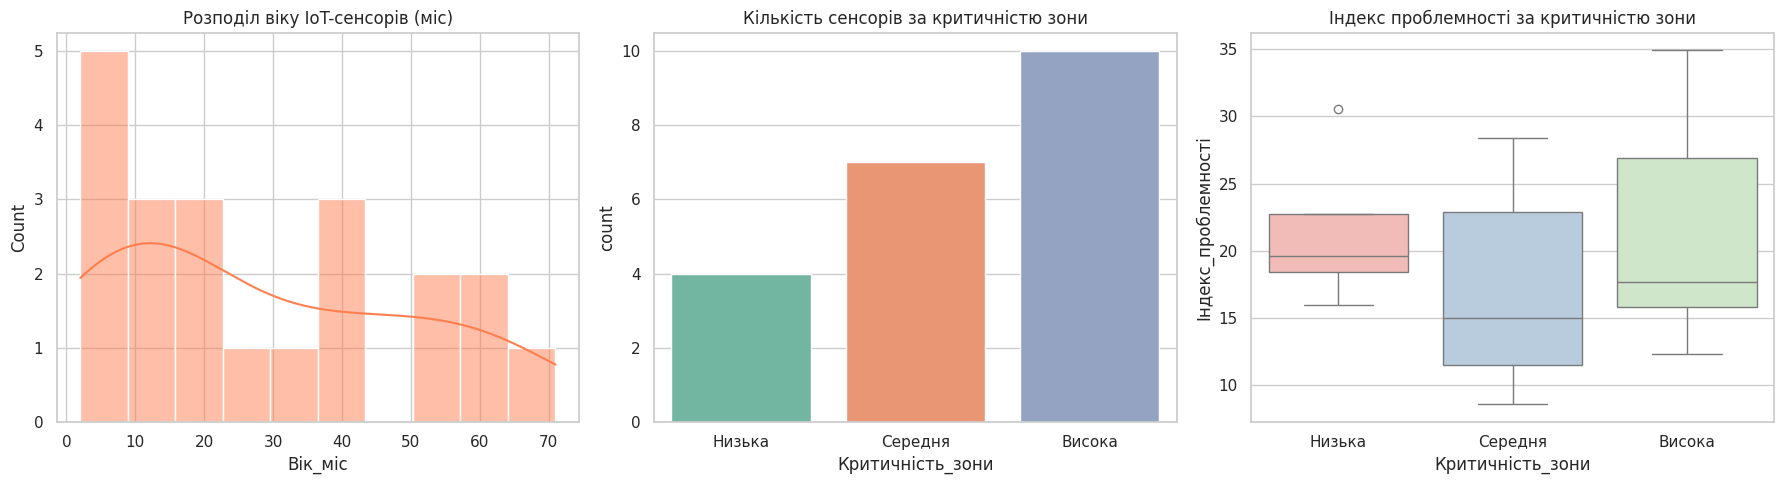

In [21]:

print("\n--- ОПИСОВІ СТАТИСТИКИ (ПІСЛЯ ОЧИЩЕННЯ) ---")
display(df.describe().T)

print("\n--- КОНТРОЛЬ ЯКОСТІ ПІСЛЯ ОЧИЩЕННЯ ---")
print('Розмір таблиці:', df.shape)
print('Пропуски:\n', df.isna().sum())

# Візуалізація
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Вік_міс'], bins=10, kde=True, ax=axes[0], color='coral')
axes[0].set_title('Розподіл віку IoT-сенсорів (міс)')

sns.countplot(x='Критичність_зони', data=df, ax=axes[1], palette='Set2', hue='Критичність_зони', legend=False)
axes[1].set_title('Кількість сенсорів за критичністю зони')

sns.boxplot(x='Критичність_зони', y='Індекс_проблемності', data=df, ax=axes[2], palette='Pastel1', hue='Критичність_зони', legend=False)
axes[2].set_title('Індекс проблемності за критичністю зони')

plt.tight_layout()
plt.show()

# 7. Висновок
Набір даних успішно очищено: виправлено формати, усунуто дублікат (IOT-05), замінено пропуски та аномалії медіанними значеннями.
Створено комплексний 'Індекс проблемності', що враховує відмови, втрату даних та стан батареї.
Дані повністю готові для використання в СППР для пріоритезації технічного обслуговування IoT-сенсорів.